Team Name : SG

Team members - VENKATESH KARDILE - SANSKRUTI GHADGE - SAMMED KARAV - JANHAVI YADAV - GENDAMALU  MAHALAKSHMI


In [2]:
# Import python libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
!pip install category_encoders
import category_encoders as ce
import pickle
import warnings
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.8 MB/s eta 0:00:00


In [3]:
# Load datasets
train_data = pd.read_csv("CS98XClassificationTrain.csv")
test_data = pd.read_csv("CS98XClassificationTest.csv")


In [21]:
# Display the first few rows of both data set
print(train_data.head())
print(test_data.head())

   Id                                        title            artist  year  \
0   1                                 My Happiness    Connie Francis  1996   
2   3                        How Deep Is Your Love          Bee Gees  1979   
3   4                                Woman in Love  Barbra Streisand  1980   
4   5  Goodbye Yellow Brick Road - Remastered 2014        Elton John  1973   
5   6                                      Grenade        Bruno Mars  2010   

        bpm      nrgy      dnce        dB  live       val  ...  \
0 -0.450411 -1.337201 -0.960594  0.219596    13 -1.293363  ...   
2 -0.529944 -1.110591  0.209212 -0.059196    13  0.301586  ...   
3  2.054860 -1.473166 -0.830616 -2.010740    13 -1.088882  ...   
4  0.106316 -0.612051 -0.245713  0.219596    15 -0.802610  ...   
5 -0.331113 -0.204155  0.729126  0.498388    12 -1.497844  ...   

       broad_genre  years_since_release  live_category_1  live_category_2  \
0  adult standards            -0.306915                0 

In [4]:
# Data Cleaning
train_data.dropna(subset=['top genre'], inplace=True)


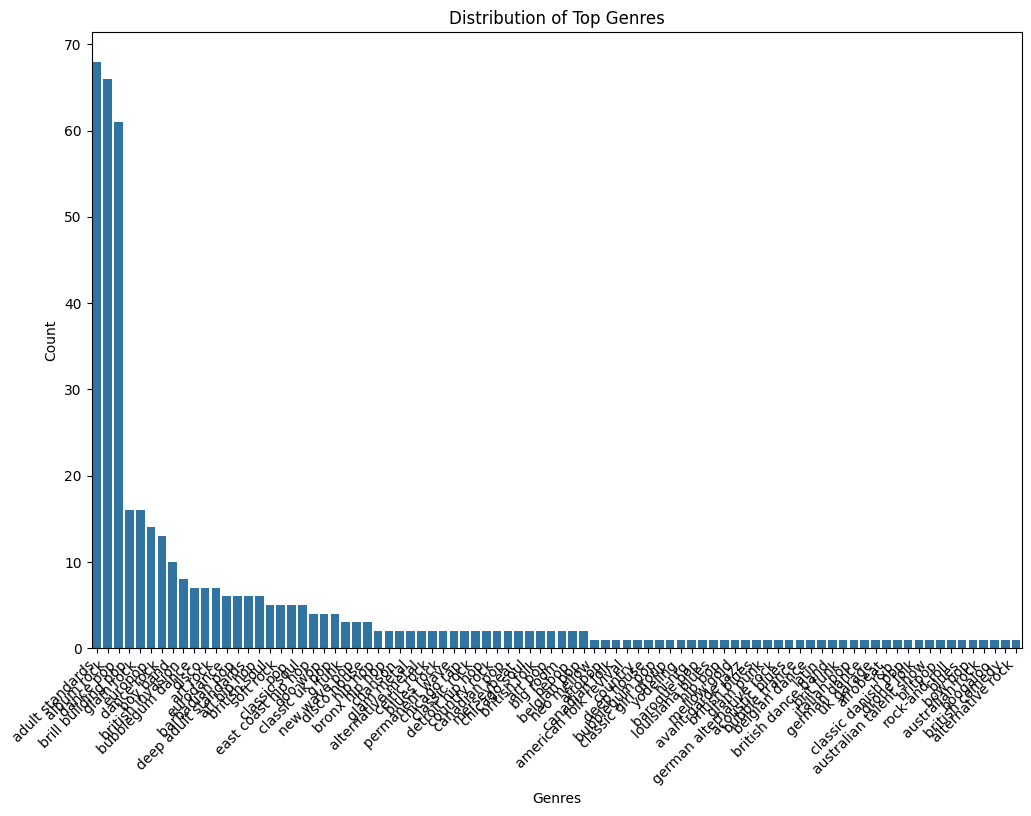

In [5]:
# Visualizing Genre Distribution (Bar Plot)
plt.figure(figsize=(12,8))
sns.barplot(x=train_data['top genre'].value_counts().index, y=train_data['top genre'].value_counts().values)
plt.title("Distribution of Top Genres")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()


In [6]:
# Convert genres with fewer than 25 occurrences into 'Other'
genre_threshold = 25
genre_counts = train_data['top genre'].value_counts()

def consolidate_genres(genre):
    return genre if genre_counts[genre] >= genre_threshold else 'Other'

train_data['broad_genre'] = train_data['top genre'].apply(consolidate_genres)


In [7]:
# Feature Engineering
train_data['years_since_release'] = datetime.datetime.now().year - train_data['year']
train_data['live_category'] = pd.cut(train_data['live'], bins=[0, 10, 15, 30, 100], labels=[1, 2, 3, 4])
train_data['speech_category'] = pd.cut(train_data['spch'], bins=[0, 3, 5, 100], labels=[1, 2, 3])


In [8]:
# Encoding Categorical Data
encoder = ce.OneHotEncoder(cols=['live_category', 'speech_category'])
encoded_features = encoder.fit_transform(train_data[['live_category', 'speech_category']])
train_data = train_data.join(encoded_features).drop(columns=['live_category', 'speech_category'])


In [9]:
# Standardize Numerical Features
scaler = StandardScaler()
numeric_features = ['bpm', 'nrgy', 'dnce', 'dB', 'val', 'dur', 'acous', 'pop', 'years_since_release']
train_data[numeric_features] = scaler.fit_transform(train_data[numeric_features])


In [10]:
# Encode Labels
label_encoder = LabelEncoder()
train_data['genre_encoded'] = label_encoder.fit_transform(train_data['broad_genre'])


In [11]:
# Split Data for Training and Testing
X = train_data[numeric_features + list(encoded_features.columns)]
y = train_data['genre_encoded']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_val)
dt_accuracy = accuracy_score(y_val, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 0.5340909090909091


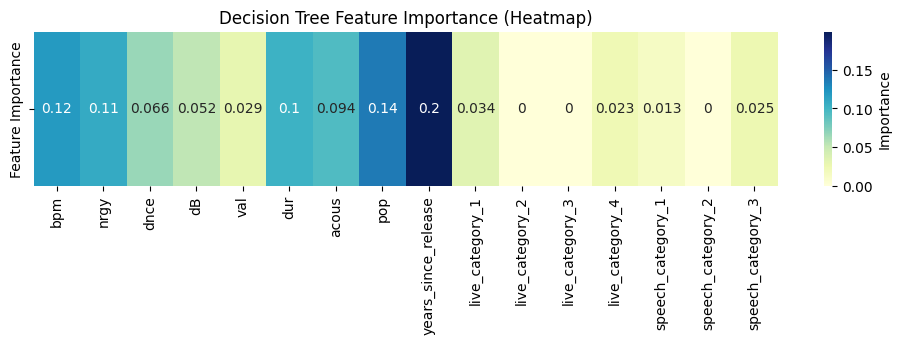

In [13]:
# Feature Importance - Decision Tree
feature_importances = dt_model.feature_importances_
importance_matrix = np.reshape(feature_importances, (1, -1))  # Reshape to 1xN matrix for heatmap
plt.figure(figsize=(12, 2))
sns.heatmap(importance_matrix, annot=True, cmap="YlGnBu", xticklabels=X.columns, yticklabels=["Feature Importance"], cbar_kws={"label": "Importance"})
plt.title("Decision Tree Feature Importance (Heatmap)")
plt.show()


In [14]:
# Train Support Vector Classifier (SVC)
svc_model = SVC(kernel='rbf', C=1.0, probability=True)
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_val)
svc_accuracy = accuracy_score(y_val, y_pred_svc)
print("SVC Accuracy:", svc_accuracy)


SVC Accuracy: 0.5568181818181818


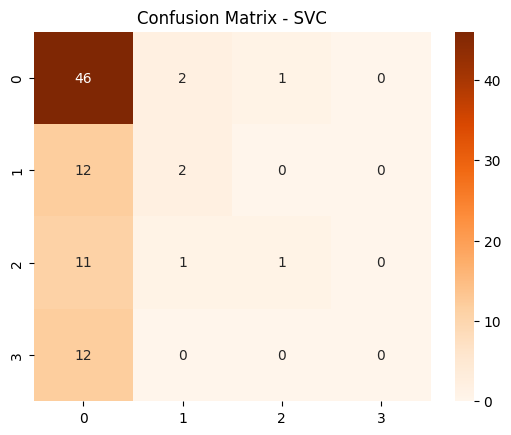

In [15]:
# Confusion Matrix - SVC (Changed color to 'Oranges')
sns.heatmap(pd.DataFrame(confusion_matrix(y_val, y_pred_svc)), annot=True, cmap="Oranges")
plt.title("Confusion Matrix - SVC")
plt.show()


In [16]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)
rf_accuracy = accuracy_score(y_val, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.5909090909090909


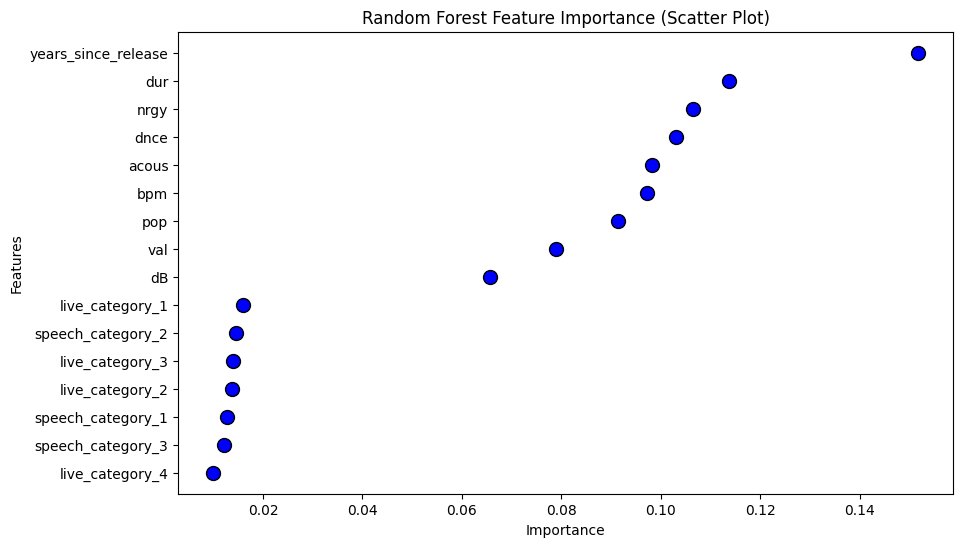

In [17]:
# Feature Importance - Random Forest (Scatter Plot with Blue Color)
importances = rf_model.feature_importances_
indices = np.argsort(importances)

# Scatter plot for feature importance with blue color
plt.figure(figsize=(10, 6))
plt.scatter(importances[indices], np.array(X.columns)[indices], color='blue', s=100, edgecolor='black')
plt.title("Random Forest Feature Importance (Scatter Plot)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


In [18]:
# Save Models
pickle.dump(dt_model, open("decision_tree.pkl", "wb"))
pickle.dump(svc_model, open("svc_model.pkl", "wb"))
pickle.dump(rf_model, open("random_forest.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(encoder, open("encoder.pkl", "wb"))
pickle.dump(label_encoder, open("label_encoder.pkl", "wb"))


In [19]:
# Create a table displaying accuracies for all models
accuracy_data = {
    'Model': ['Decision Tree', 'SVC', 'Random Forest'],
    'Accuracy': [dt_accuracy, svc_accuracy, rf_accuracy]
}

accuracy_df = pd.DataFrame(accuracy_data)

# Display accuracy table using pandas
print("\nModel Accuracies:")
print(accuracy_df)



Model Accuracies:
           Model  Accuracy
0  Decision Tree  0.534091
1            SVC  0.556818
2  Random Forest  0.590909
